# Python Fundamentals II

### MPATE-GE 2598 Fundamentals of Digital Signal Theory Lab

Adapted from [Introduction to Data Science with Python](https://nustat.github.io/DataScience_Intro_python/Introduction%20to%20Python%20and%20Jupyter%20Notebooks.html) by Northwestern University's Department of Statistics and Data Science.

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

## More NumPy

NumPy requires that all elements (items) have the same data type.
If not, it forces all of the elements to conform to the same data type.
This goes back to efficiency (computations are much less expensive).

In [2]:
# lists let you have items with different data types
mixed_num = [90, 5, 72, 4.2, 38.56]

# once you convert it into an array, all elements are forced to have the same type
mixed_num_arr = np.array(mixed_num)

print("Items in List:")
for item in mixed_num:
    print(type(item))

print("\nItems in Array:")
for item in mixed_num_arr:
    print(type(item))

Items in List:
<class 'int'>
<class 'int'>
<class 'int'>
<class 'float'>
<class 'float'>

Items in Array:
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>


In [3]:
mixed_num_arr

array([90.  ,  5.  , 72.  ,  4.2 , 38.56])

In [4]:
# another example, but also include strings
num_words = [2.19, 'four', 104, 'cat']

# convert to an array
num_words_arr = np.array(num_words)

print("Items in List:")
for item in num_words:
    print(type(item))

print("\nItems in Array:")
for item in num_words_arr:
    print(type(item))

Items in List:
<class 'float'>
<class 'str'>
<class 'int'>
<class 'str'>

Items in Array:
<class 'numpy.str_'>
<class 'numpy.str_'>
<class 'numpy.str_'>
<class 'numpy.str_'>


In [5]:
num_words_arr

array(['2.19', 'four', '104', 'cat'], dtype='<U32')

There are some shortcuts to pre-fill an array in NumPy.
The main information you need to provide is what shape you want the array to be.
Do this by passing in either a list or a tuple of how many elements are in each dimension.

In [6]:
# pass in the dimensions as a list
zero_arr = np.zeros([4, 7])
print(f"An array of all 0s:\n{zero_arr}")

An array of all 0s:
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


In [7]:
# pass in the dimensions as a tuple
ones_arr = np.ones((3, 5, 8))
print(f"An array of all 1s:\n{ones_arr}")

An array of all 1s:
[[[1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1.]]]


## Working with Audio

The main package we use to load and save audio in Python is called `soundfile`.
If you are using a recent version of `librosa`, it should be installed automatically.

In [8]:
# uncomment and run the command below if you need to install soundfile
# !pip install soundfile

In [9]:
# load the soundfile package using an alias
import soundfile as sf

### Read
We use the `read()` function to load an audio file into Python using the `soundfile` package.
It has one required argument (or parameter), which is the path to the file. Make sure you put your audio file in the same folder as your notebook to easily access it.

In [10]:
# .wav from: https://freesound.org/people/delphidebrain/sounds/236040/
# what is the output of this function?
y, sr = sf.read('bark_howl.wav')

In [11]:
y

array([0., 0., 0., ..., 0., 0., 0.], shape=(112384,))

In [12]:
# what does this number represent?
# how do you know if the file is in mono or stereo?
print(f"shape of y: {y.shape}")

shape of y: (112384,)


In [13]:
# y_stereo, sr = sf.read('bark_howl_stereo.wav')
# print(y_stereo.shape)
# output: (112384, 2)

In [14]:
# what is the sample rate?
print(f"sample rate: {sr} Hz")

sample rate: 44100 Hz


### Playback

To play audio in our notebook, we need to use a function that specifically renders an audio player in Jupyter.

In [15]:
# import the playback function
from IPython.display import Audio

In [16]:
# call the function
# check the inputs
# what information do we need to provide to successfully play the audio?
Audio(y, rate=sr, normalize=False)

### Waveform

The main package we use for plotting is `matplotlib`.
Specifically, we utilize the subpackage `pyplot`, which we just shorten to `plt`.
`plt` provides an object-oriented interface where we can "layer" objects in a figure to make a plot.
This includes: data points, axes, labels, titles, etc.

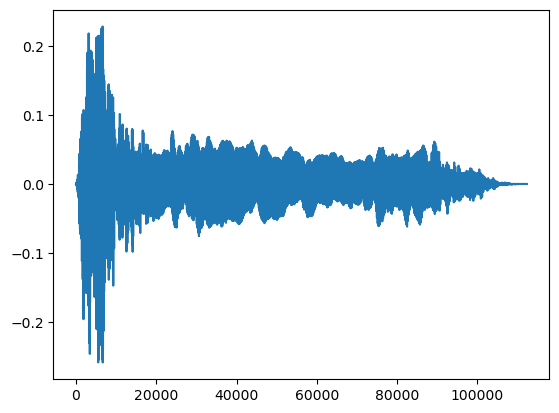

In [17]:
# add the audio data
plt.plot(y)
# show the plot (optional)
plt.show()
# what is on the x-axis and y-axis?

Right now, we are seeing each sample as a value in an array with no temporal information encoded into the plot.
In order to change the x-axis to represent time, we need to know at what point in time each sample is being played.
The key piece of information we need to figure this out is the sample rate ($f_s$).

In [18]:
# how do we get the total time of the audio file?
n_samples = len(y)
total_t = n_samples / sr
print(f"The audio file is {total_t} seconds long.")

The audio file is 2.5483900226757368 seconds long.


In [19]:
# now we can make a time vector using this very nifty numpy function
t = np.linspace(0, total_t, num=n_samples)

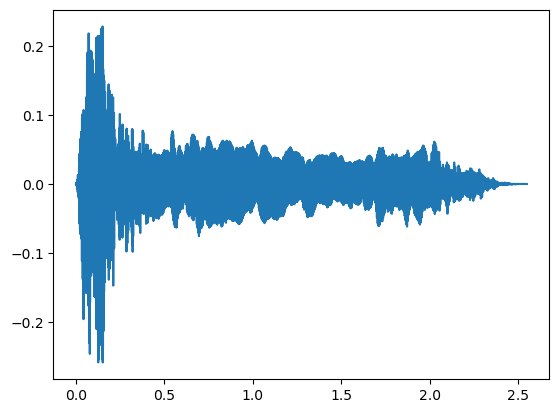

In [20]:
# plot the audio data against time
plt.plot(t, y)  # time on the x-axis
plt.show()

### Normalization

You will notice that the range of the audio file is from around -0.2 to +0.2.
If we load a different file, we may have a completely different range of amplitudes, and thus, a different perceived loudness.
Typically, we want to _normalize_ audio files by adjusting the volume to a target level so that the loudness is consistent between tracks.
A common range to target your WAV files to is -1 to +1.

Please note that normalization and compression are **not** the same thing. Normalization does not change the relative dynamic range of samples to one another.

In [21]:
# to normalize, we need to scale each sample
# we want the loudest sample to be +/- 1 and everything else relative to that
# how do we do this?
y_norm = y / np.max(np.abs(y))

In [22]:
# playback the normalized audio
# has the sample rate changed?
Audio(y_norm, rate=sr, normalize=False)

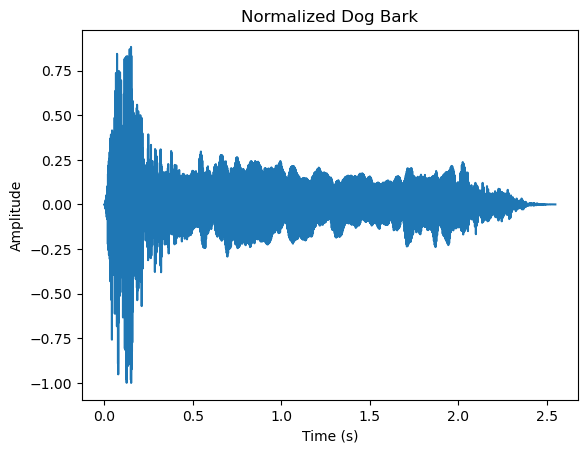

In [23]:
# has the time vector changed?
# no, all we did was change the amplitude of each sample
# temporally, there is no change
plt.plot(t, y_norm)

# add labels to the horizontal axis
plt.xlabel('Time (s)')
# add a label to the veritcal axis
plt.ylabel('Amplitude')
# add a title to the figure
plt.title('Normalized Dog Bark')
plt.show()

### Write

Similar to the `read()` function from `soundfile`, there is also a `write` function which you can use to save audio files from Python to your computer.

There are three required inputs to this function: `file`, `data`, and `samplerate`. `file` is the name and location of the desired output file.

In [24]:
# save the normalized bark audio as a new file called bark_howl_norm.wav
# this will save it in the same directory as my notebook
# provide the audio data and the sample rate
sf.write('bark_howl_norm.wav', y_norm, sr)

In [25]:
# check that it was saved properly
Audio(filename='bark_howl_norm.wav')

***
_End of Class 3_